In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
df=pd.read_csv('data/divorce_data.csv',delimiter=';')

In [21]:
df.isna().sum()

Q1         0
Q2         0
Q3         0
Q4         0
Q5         0
Q6         0
Q7         0
Q8         0
Q9         0
Q10        0
Q11        0
Q12        0
Q13        0
Q14        0
Q15        0
Q16        0
Q17        0
Q18        0
Q19        0
Q20        0
Q21        0
Q22        0
Q23        0
Q24        0
Q25        0
Q26        0
Q27        0
Q28        0
Q29        0
Q30        0
Q31        0
Q32        0
Q33        0
Q34        0
Q35        0
Q36        0
Q37        0
Q38        0
Q39        0
Q40        0
Q41        0
Q42        0
Q43        0
Q44        0
Q45        0
Q46        0
Q47        0
Q48        0
Q49        0
Q50        0
Q51        0
Q52        0
Q53        0
Q54        0
Divorce    0
dtype: int64

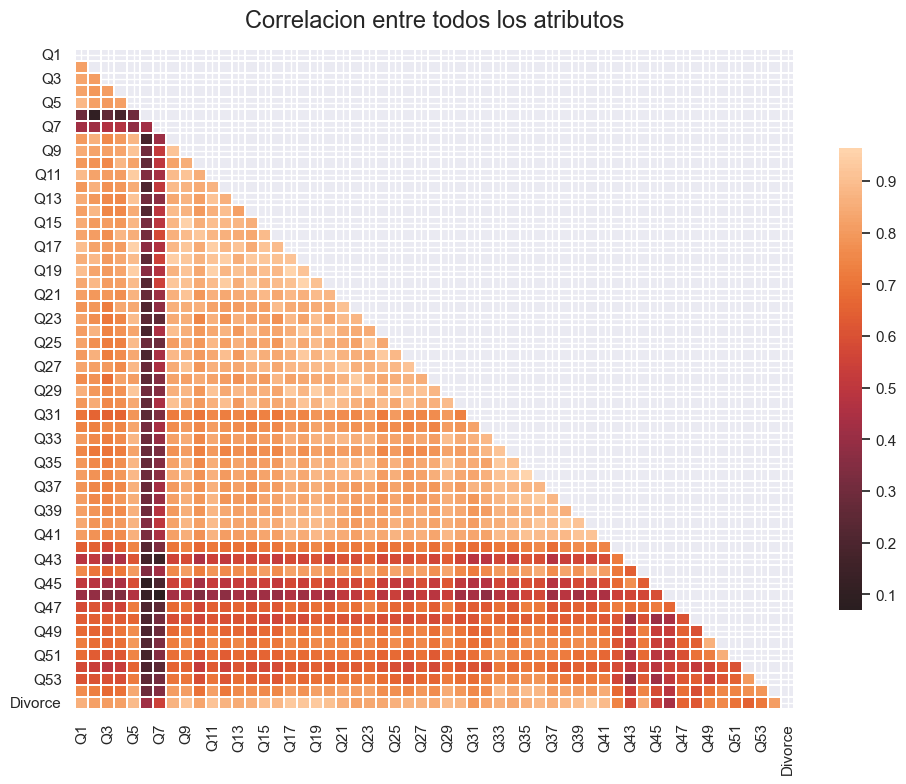

In [22]:
fig,ax = plt.subplots(figsize=(10,8))

heat_df = df.corr()
plt.title("Correlacion entre todos los atributos", fontsize=17,y=1.02)
sns.color_palette("magma", as_cmap=True)
mask = np.triu(np.ones_like(heat_df, dtype=bool))
sns.heatmap(data=heat_df,annot=False,mask=mask,center=0,linewidths=0.3,annot_kws={"fontsize":12},cbar_kws={"shrink": .7});

plt.tight_layout()

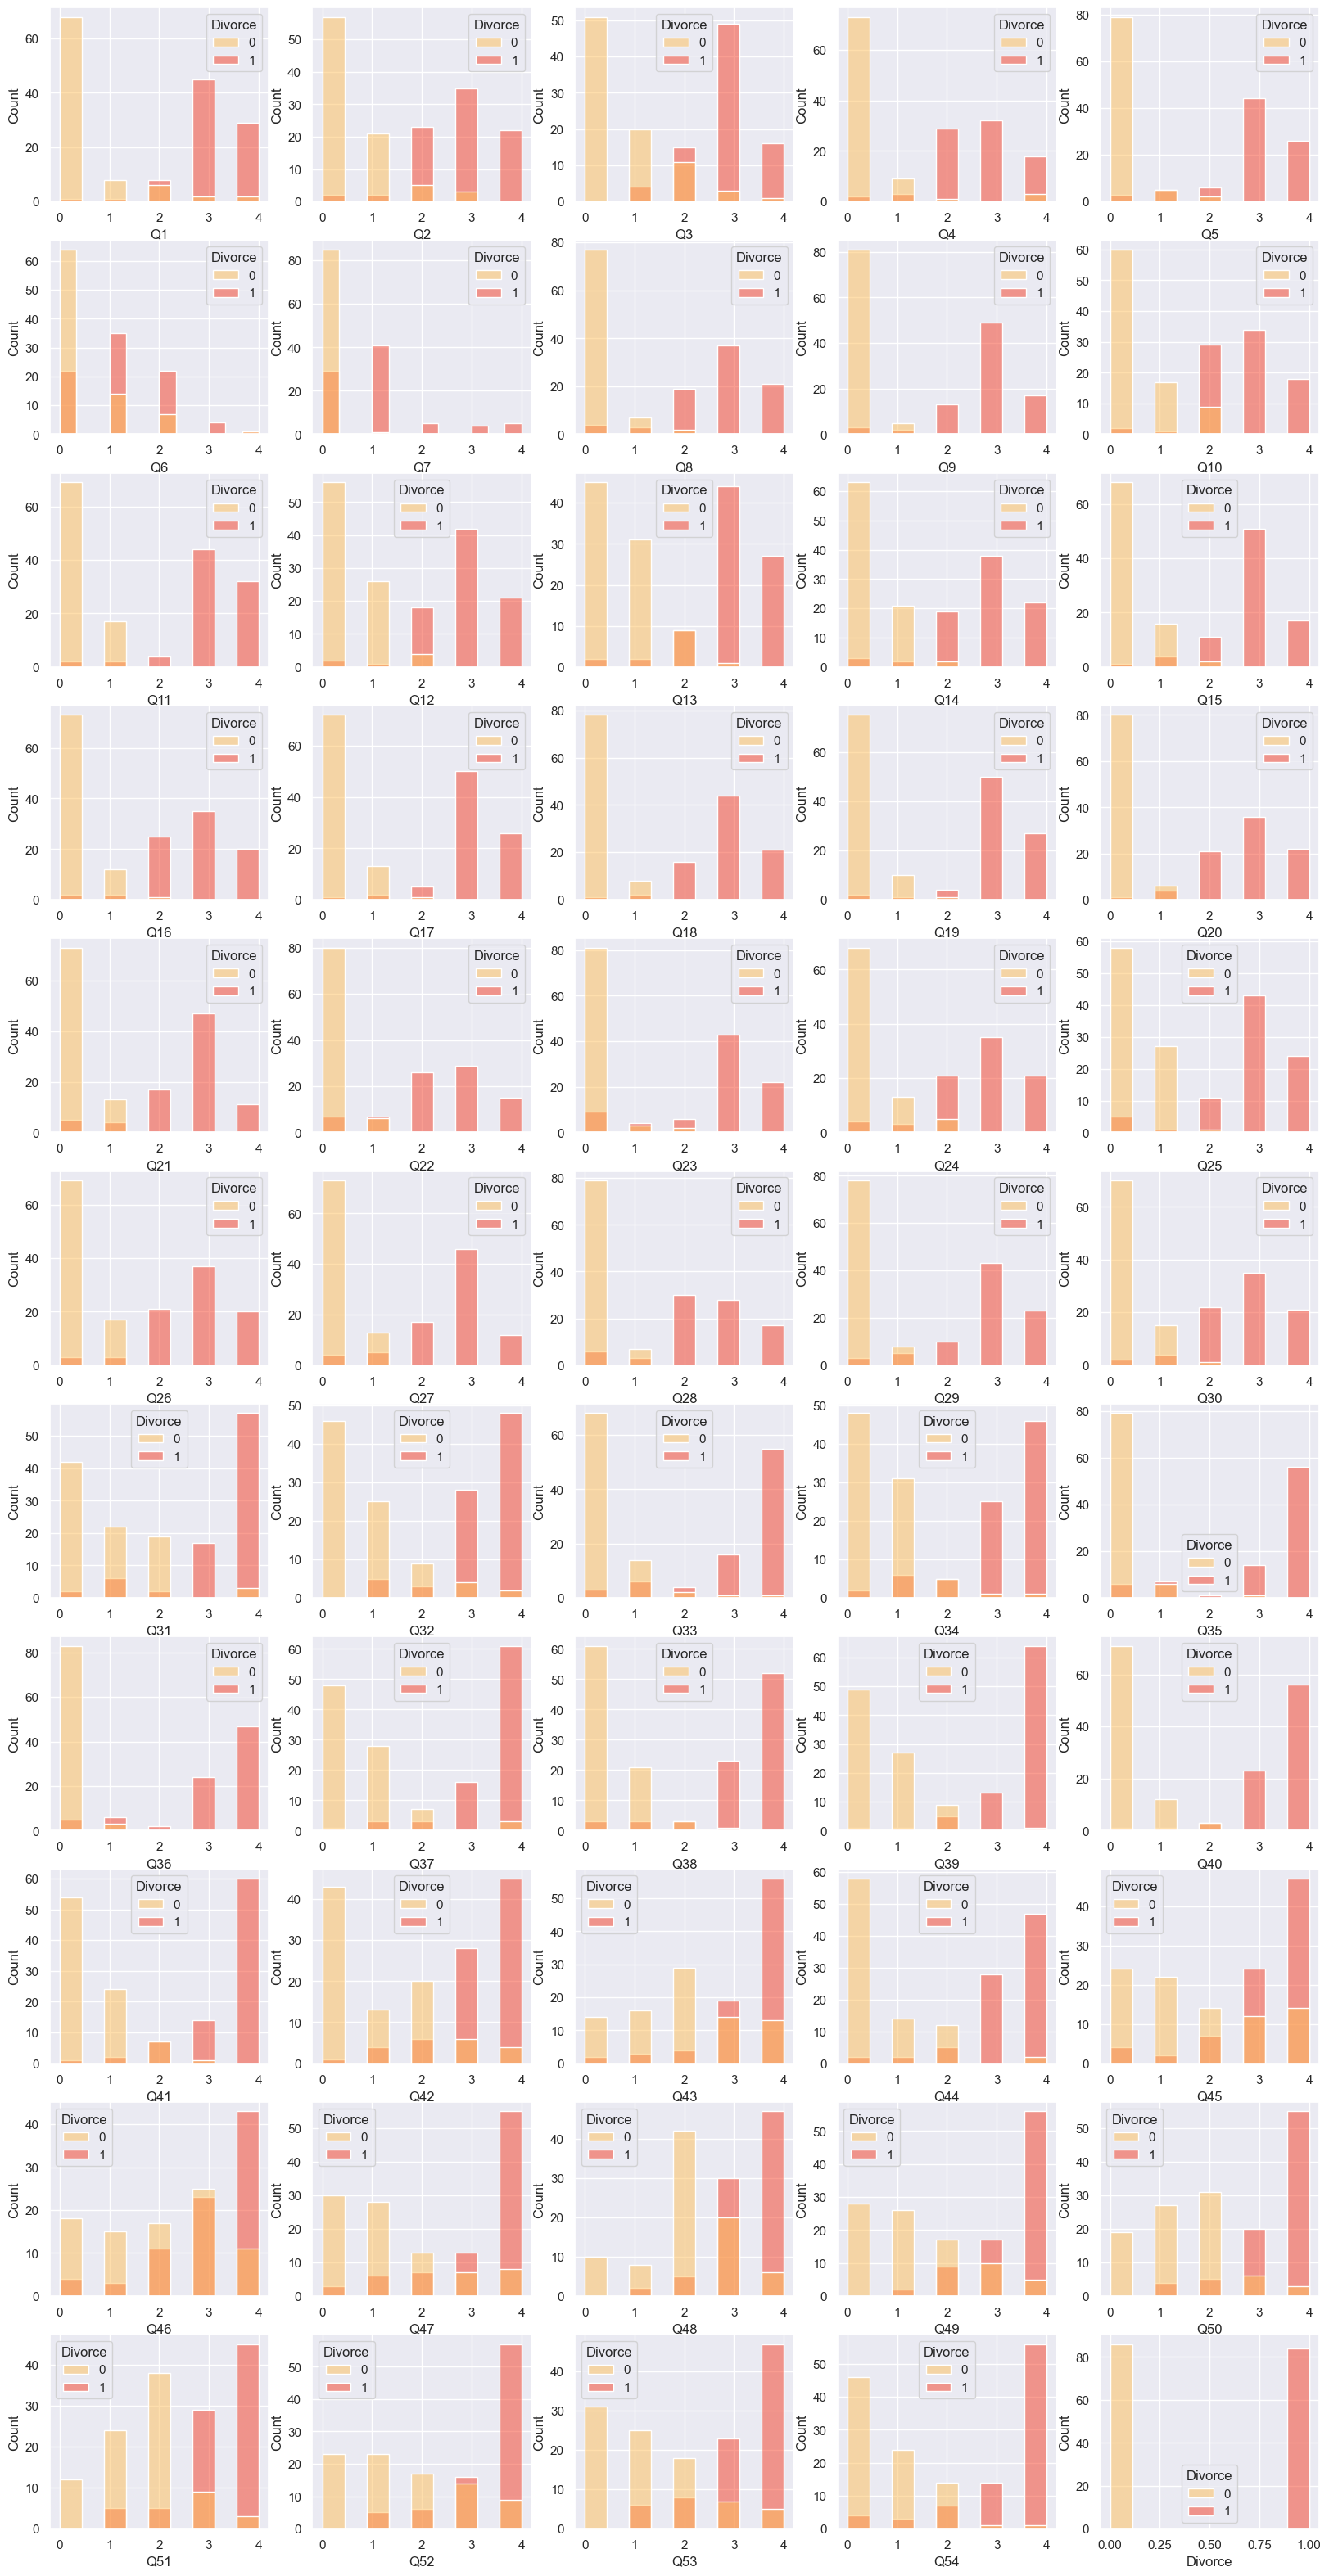

In [23]:
sns.set(rc={'figure.figsize':(20,40)})
for i, column in enumerate(list(df.columns), 1):
    plt.subplot(11,5,i)
    p=sns.histplot(x=column,data=df,hue="Divorce",stat='count',palette='YlOrRd')

In [24]:
X=df.drop(axis=1,columns=['Divorce'])
y=df.Divorce

scaler = StandardScaler()
scaler.fit_transform(X);

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=0),
}


================ Logistic Regression ================
Overall Accuracy: 94.12%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.89      0.94        18

    accuracy                           0.94        34
   macro avg       0.94      0.94      0.94        34
weighted avg       0.95      0.94      0.94        34



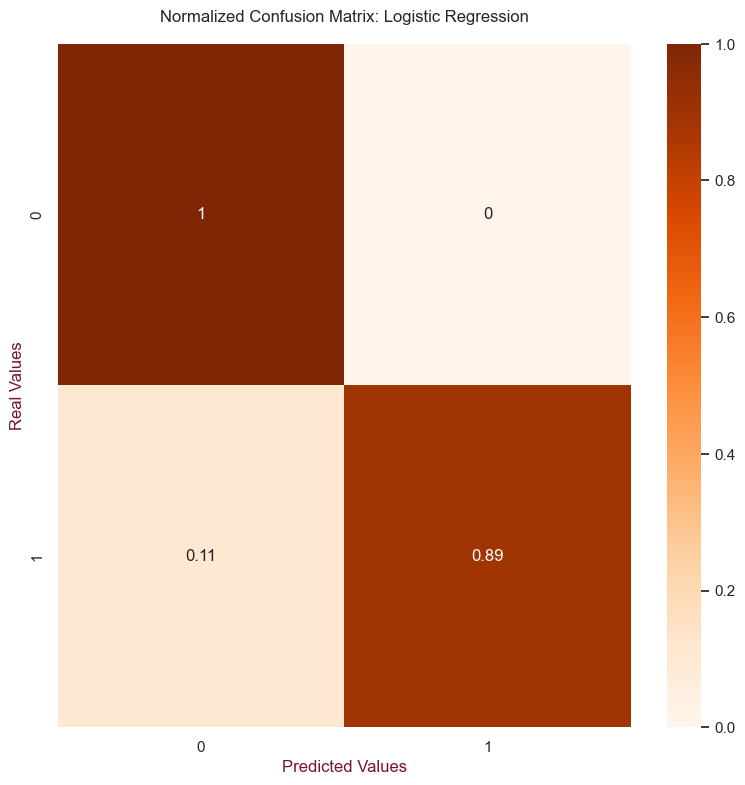


================ Random Forest ================
Overall Accuracy: 94.12%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       1.00      0.89      0.94        18

    accuracy                           0.94        34
   macro avg       0.94      0.94      0.94        34
weighted avg       0.95      0.94      0.94        34



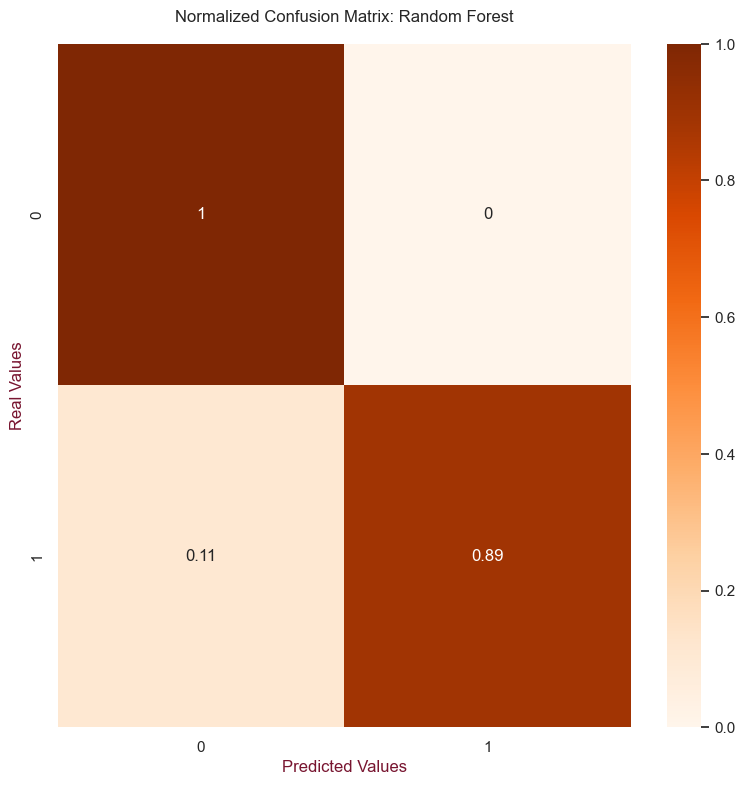

/var/folders/xk/1rld6vfd1wg4hnmdkv7sx_b00000gn/T/ipykernel_42345/2575204252.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


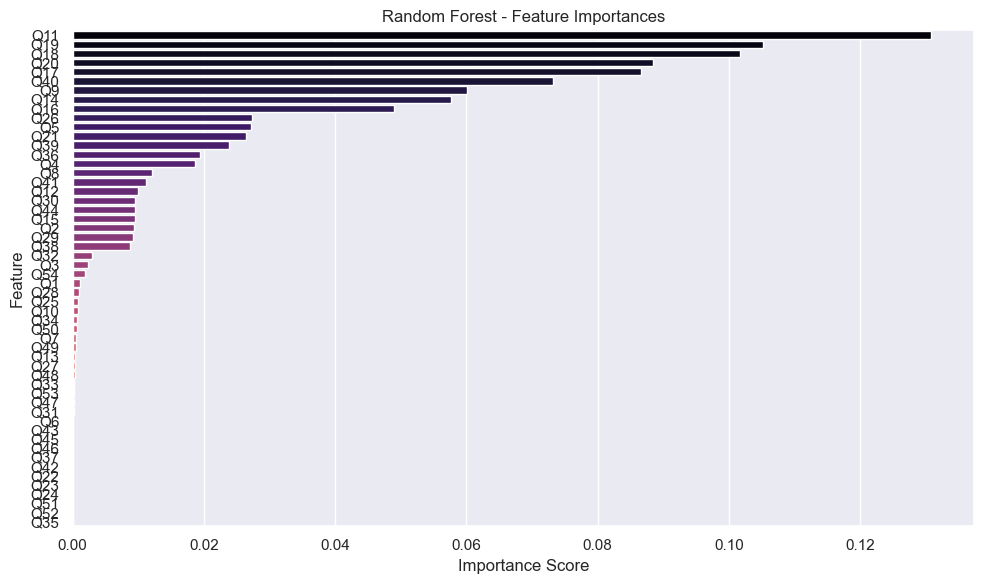


Top 10 Most Important Features:
  1. Q11: 0.1308
  2. Q19: 0.1052
  3. Q18: 0.1017
  4. Q20: 0.0885
  5. Q17: 0.0866
  6. Q40: 0.0731
  7. Q9: 0.0601
  8. Q14: 0.0576
  9. Q16: 0.0489
  10. Q26: 0.0274

--- Final Model Comparison ---
Logistic Regression: 94.12%
Random Forest: 94.12%


In [27]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n================ {name} ================")
    print(f"Overall Accuracy: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Normalized confusion matrix
    fig, ax = plt.subplots(figsize=(8, 8))
    norm_conf = [i for i in confusion_matrix(y_test, y_pred)]
    norm_conf[0] = norm_conf[0] / norm_conf[0].sum()
    norm_conf[1] = norm_conf[1] / norm_conf[1].sum()
    sns.heatmap(data=norm_conf, annot=True, ax=ax, cmap='Oranges')
    ax.set_title(f"Normalized Confusion Matrix: {name}", y=1.02)
    ax.set_ylabel("Real Values", c="#781530")
    ax.set_xlabel("Predicted Values", c="#781530")
    plt.tight_layout()
    plt.show()

    if name == "Random Forest":
        feature_names = df.drop(columns=['Divorce']).columns
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        sns.barplot(
            x=importances[indices],
            y=feature_names[indices],
            palette='magma'
        )
        plt.title('Random Forest - Feature Importances')
        plt.xlabel('Importance Score')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

        # Also print top 10
        print("\nTop 10 Most Important Features:")
        for i in range(min(10, len(feature_names))):
            print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}") 


print("\n--- Final Model Comparison ---")
for model_name, score in results.items():
    print(f"{model_name}: {score * 100:.2f}%")